# Four-bar linkage — end-to-end demo (Argentina)

1. **Define** the mechanism (5 joints, one rotary actuator on joints 0-1).
2. **Simulate** + plot the path-node trajectory; `reachable_arc` joins the
   wrap-around arc for the (non-Grashof) wishlist 4-bar.
3. **Perturb** PSlice with small noise and simulate again.
4. **Optimize** from the perturbed start back toward the baseline trace
   (soft-chamfer + L-BFGS).
5. **Compare** original / perturbed / optimized.
6. **Metric study** — same fit with four metrics + wall-clock timings.
7. **Export** the recovered config to `.txt` + MotionGen JSON (with the
   rotary actuator).

The kinematic structure stays the same throughout; only PSlice changes.


## Setup


In [ ]:
# On Colab: locate the Argentina helpers in your Google Drive.
import os, sys
IN_COLAB = 'google.colab' in sys.modules
HELPERS = ['simulator.py', 'optimizer.py', 'visualizer.py', 'motiongen_export.py', 'normalize.py', 'bsi_converter.py']

if IN_COLAB and not any(os.path.isfile(h) for h in HELPERS):
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        print('Mounting Google Drive (auth prompt) ...')
        drive.mount('/content/drive')
    for c in ['/content/drive/MyDrive/Argentina',
              '/content/drive/My Drive/Argentina']:
        if any(os.path.isfile(os.path.join(c, h)) for h in HELPERS):
            os.chdir(c)
            if c not in sys.path:
                sys.path.insert(0, c)
            print(f'workdir -> {c}')
            break
    else:
        print('WARNING: Argentina/ folder not found in Drive with the helper .py files.')
        print('         Either upload .py files to /content, or run os.chdir() yourself.')

In [1]:
import os, json, sys, time, datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import torch

HERE = os.getcwd()
ARG_DIR = HERE if os.path.basename(HERE) == 'Argentina' else os.path.join(HERE, 'Argentina')
if ARG_DIR not in sys.path:
    sys.path.insert(0, ARG_DIR)

from simulator import sort_mechanism, simulate_batch_no_grad, reachable_arc
from optimizer import (
    fit_to_expected_path, optimize_mechanism, normalize_curve,
)
from visualizer import save_config_txt
from motiongen_export import build_motiongen_json, copy_to_clipboard

DTYPE = torch.float64
np.random.seed(0)
print('ready - torch', torch.__version__, ', numpy', np.__version__)


ready - torch 2.11.0+cu128 , numpy 2.4.6


## Step 1 - Define the four-bar

| idx | role | initial position |
|-----|------|------------------|
| 0 | ground / motor pivot (fixed) | (0, 0) |
| 1 | driven crank tip (actuator output) | (1, 2) |
| 2 | other ground pivot (fixed) | (4, 0) |
| 3 | rocker joint (moving) | (3, 2) |
| 4 | **path node** on the coupler body {1, 3, 4} | (2, 3) |


In [2]:
JJ = np.array([
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1],
    [0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1],
    [0, 1, 0, 1, 0],
], dtype=int)
PSlice = np.array([
    [0.0, 0.0],
    [1.0, 2.0],
    [4.0, 0.0],
    [3.0, 2.0],
    [2.0, 3.0],
])
motor       = [0, 1]
fixed_nodes = [0, 2]
path_node   = 4

D = np.linalg.norm(PSlice[:, None, :] - PSlice[None, :, :], axis=-1)
edges = [(0, 1), (1, 3), (2, 3), (1, 4), (3, 4)]
print('Link lengths:')
for a, b in edges:
    print(f'  {a}-{b}: {D[a, b]:.3f}')
print(f'Ground span 0-2: {D[0, 2]:.3f}')
loop = sorted([D[0, 1], D[1, 3], D[2, 3], D[0, 2]])
s, p, q, l = loop
print(f'\nGrashof: s+l = {s + l:.3f}, p+q = {p + q:.3f}',
      '-> Grashof' if s + l <= p + q else '-> NON-Grashof (rocker only)')


Link lengths:
  0-1: 2.236
  1-3: 2.000
  2-3: 2.236
  1-4: 1.414
  3-4: 1.414
Ground span 0-2: 4.000

Grashof: s+l = 6.000, p+q = 4.472 -> NON-Grashof (rocker only)


## Step 2 - Baseline simulation


reachable arc - mode=wrap, start=156, end=44, count=89/200 (44%)


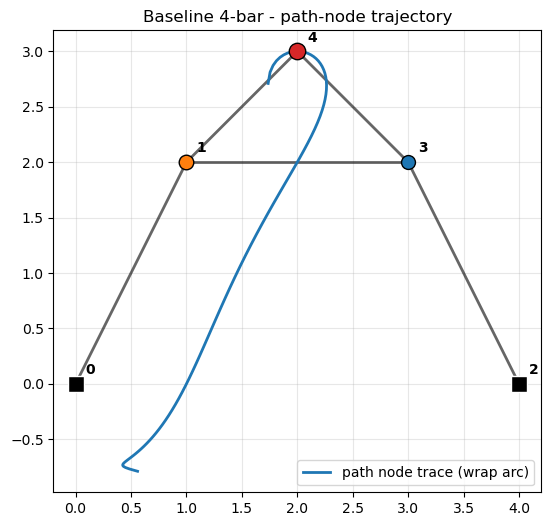

In [3]:
def simulate_path(PSlice_, n_theta=200):
    JJ_s, PS_s, _, fn_s, ord_ = sort_mechanism(JJ, PSlice_, motor, fixed_nodes)
    N = JJ_s.shape[0]
    n_t = np.zeros([N, 1]);  n_t[fn_s] = 1
    JJs   = torch.as_tensor(JJ_s[None],   dtype=DTYPE)
    PSls  = torch.as_tensor(PS_s[None],   dtype=DTYPE)
    nts   = torch.as_tensor(n_t[None],    dtype=DTYPE)
    ths   = torch.linspace(0, 2 * np.pi, n_theta + 1, dtype=DTYPE)[:n_theta]
    sol   = simulate_batch_no_grad(JJs, PSls, nts, ths)[0].cpu().numpy()
    inv = np.empty_like(ord_); inv[ord_] = np.arange(N)
    sol_o = sol[inv]
    return sol_o, sol_o[path_node]

def draw_mechanism(ax, PSlice_):
    for a, b in edges:
        ax.plot([PSlice_[a, 0], PSlice_[b, 0]],
                [PSlice_[a, 1], PSlice_[b, 1]], '-', color='black', lw=2, alpha=0.6)
    for k in range(PSlice_.shape[0]):
        if k in fixed_nodes:
            ax.scatter(*PSlice_[k], s=120, marker='s', color='black',
                       edgecolor='white', zorder=5)
        elif k == path_node:
            ax.scatter(*PSlice_[k], s=140, marker='o', color='#d62728',
                       edgecolor='black', zorder=5)
        elif k == motor[1]:
            ax.scatter(*PSlice_[k], s=110, marker='o', color='#ff7f0e',
                       edgecolor='black', zorder=5)
        else:
            ax.scatter(*PSlice_[k], s=100, marker='o', color='#1f77b4',
                       edgecolor='black', zorder=5)
        ax.annotate(f'{k}', PSlice_[k], xytext=(7, 7),
                    textcoords='offset points', fontsize=10, fontweight='bold')

sol_base, trace_base = simulate_path(PSlice)
arc_base, info_base = reachable_arc(trace_base)
print(f"reachable arc - mode={info_base['mode']}, "
      f"start={info_base['start']}, end={info_base['end']}, "
      f"count={info_base['count']}/{trace_base.shape[0]} "
      f"({100*info_base['fraction']:.0f}%)")

fig, ax = plt.subplots(figsize=(7, 6))
draw_mechanism(ax, PSlice)
ax.plot(arc_base[:, 0], arc_base[:, 1], '-', color='#1f77b4',
        lw=2.0, label=f"path node trace ({info_base['mode']} arc)")
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(loc='best')
ax.set_title('Baseline 4-bar - path-node trajectory')
plt.show()


## Step 3 - Perturb PSlice with small noise


In [4]:
noise_std = 0.10
noise = noise_std * np.random.randn(*PSlice.shape)
PSlice_perturbed = PSlice + noise
print('perturbation (per joint):')
for k in range(PSlice.shape[0]):
    dx, dy = noise[k]
    print(f'  joint {k}: dx={dx:+.3f}, dy={dy:+.3f}  '
          f'-> ({PSlice_perturbed[k, 0]:+.3f}, {PSlice_perturbed[k, 1]:+.3f})')

sol_p, trace_p = simulate_path(PSlice_perturbed)
arc_p, info_p = reachable_arc(trace_p)
print(f"\nperturbed - mode={info_p['mode']}, count={info_p['count']}/{trace_p.shape[0]}")


perturbation (per joint):
  joint 0: dx=+0.176, dy=+0.040  -> (+0.176, +0.040)
  joint 1: dx=+0.098, dy=+0.224  -> (+1.098, +2.224)
  joint 2: dx=+0.187, dy=-0.098  -> (+4.187, -0.098)
  joint 3: dx=+0.095, dy=-0.015  -> (+3.095, +1.985)
  joint 4: dx=-0.010, dy=+0.041  -> (+1.990, +3.041)

perturbed - mode=wrap, count=91/200


## Step 4 - Compare baseline vs perturbed


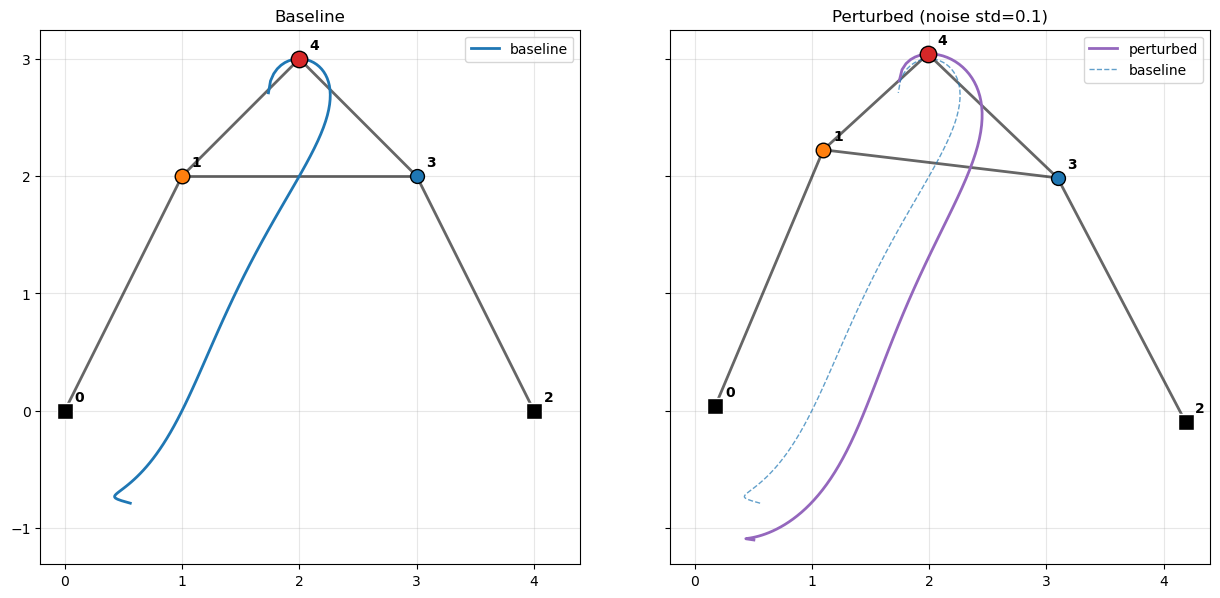

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
draw_mechanism(axes[0], PSlice)
axes[0].plot(arc_base[:, 0], arc_base[:, 1], color='#1f77b4', lw=2.0, label='baseline')
axes[0].set_title('Baseline'); axes[0].set_aspect('equal'); axes[0].grid(alpha=0.3); axes[0].legend()
draw_mechanism(axes[1], PSlice_perturbed)
axes[1].plot(arc_p[:, 0], arc_p[:, 1], color='#9467bd', lw=2.0, label='perturbed')
axes[1].plot(arc_base[:, 0], arc_base[:, 1], color='#1f77b4', lw=1.0, ls='--', alpha=0.7, label='baseline')
axes[1].set_title(f'Perturbed (noise std={noise_std})')
axes[1].set_aspect('equal'); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()


## Step 5 - Optimize back toward the baseline (default: soft-chamfer + anneal)


L-BFGS converged: 80 outer steps, loss 2.6918e-02 -> 6.0894e-04 (97.7% reduction)


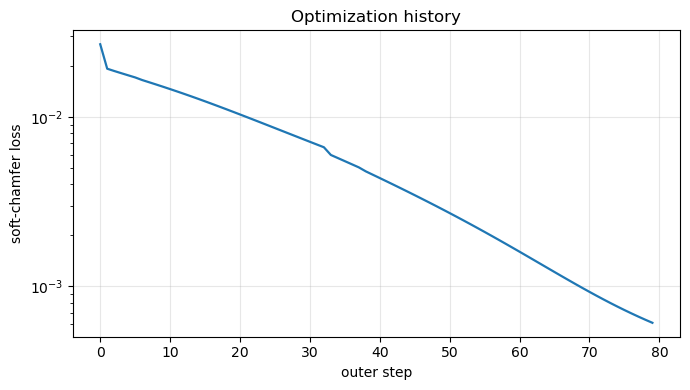

In [6]:
res = fit_to_expected_path(
    JJ, PSlice_perturbed, arc_base,
    motor=motor, fixed_nodes=fixed_nodes, path_node=path_node,
    method='lbfgs', metric='soft_chamfer',
    n_outer=80, lr=0.3, tau_anneal=True,
    verbose=False,
)
PSlice_opt = res['x_optimized']
hist = res['history']
print(f"L-BFGS converged: {len(hist)} outer steps, "
      f"loss {hist[0]:.4e} -> {hist[-1]:.4e} "
      f"({100 * (1 - hist[-1] / max(hist[0], 1e-30)):.1f}% reduction)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(hist, lw=1.6)
ax.set_xlabel('outer step'); ax.set_ylabel('soft-chamfer loss')
ax.set_title('Optimization history'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Step 6 - Overlay baseline / perturbed / optimized


optimized - mode=wrap, count=93/200


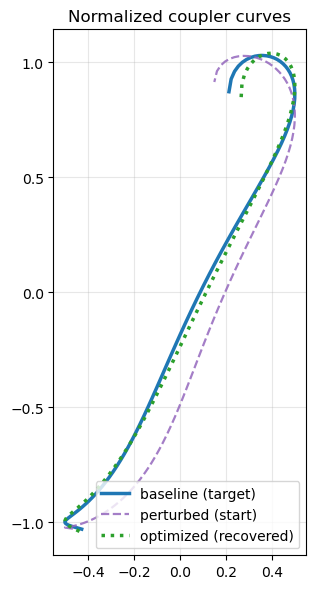

In [7]:
sol_o, trace_o = simulate_path(PSlice_opt)
arc_o, info_o = reachable_arc(trace_o)
print(f"optimized - mode={info_o['mode']}, count={info_o['count']}/{trace_o.shape[0]}")

def _norm_np(c):
    t = torch.as_tensor(c, dtype=DTYPE)
    return normalize_curve(t).cpu().numpy()

nb_norm = _norm_np(arc_base); np_norm = _norm_np(arc_p); no_norm = _norm_np(arc_o)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(nb_norm[:, 0], nb_norm[:, 1], '-',  color='#1f77b4', lw=2.5, label='baseline (target)')
ax.plot(np_norm[:, 0], np_norm[:, 1], '--', color='#9467bd', lw=1.6, alpha=0.85, label='perturbed (start)')
ax.plot(no_norm[:, 0], no_norm[:, 1], ':',  color='#2ca02c', lw=2.5, label='optimized (recovered)')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Normalized coupler curves')
plt.tight_layout(); plt.show()


## Step 7 - Metric study: soft-chamfer vs hausdorff vs combined vs soft-DTW

Same fit from the perturbed PSlice, run four times with different metrics.
`fit_to_expected_path` accepts a list of metrics with optional
`metric_weights`.

The cell below also **times each configuration** so you can see the
trade-off: soft-DTW (divergence form) does ~3 anti-diagonal sweeps per
loss eval, so it's slower than chamfer/hausdorff but still seconds, not
minutes.


In [12]:
EXPERIMENTS = [
    ('soft_chamfer',                          dict(metric='soft_chamfer', tau_anneal=True)),
    ('hausdorff',                             dict(metric='hausdorff',    tau_anneal=False)),
    ('soft_chamfer + hausdorff',              dict(metric=['soft_chamfer', 'hausdorff'],
                                                  metric_weights=[1.0, 4.0],
                                                  tau_anneal=True)),
    ('soft_dtw',                              dict(metric='soft_dtw',     tau_anneal=False)),
]

def time_config(label, kw, n_outer=120, lr=0.1):
    """Run one optimizer config and return result dict + wall time."""
    t0 = time.perf_counter()
    res_m = fit_to_expected_path(
        JJ, PSlice_perturbed, arc_base,
        motor=motor, fixed_nodes=fixed_nodes, path_node=path_node,
        method='lbfgs', n_outer=n_outer, lr=lr,
        verbose=False, **kw,
    )
    elapsed = time.perf_counter() - t0
    _, trace_m = simulate_path(res_m['x_optimized'])
    arc_m, _ = reachable_arc(trace_m)
    hist_m = res_m['history']
    return dict(PSlice=res_m['x_optimized'], arc=arc_m, hist=hist_m,
                elapsed=elapsed, n_outer=n_outer, lr=lr)

results = {}
for label, kw in EXPERIMENTS:
    print(f'--- {label} ---')
    # use n_outer=60 for faster response; n_outer=120 + lr=0.05 for cleaner convergence
    r = time_config(label, kw, n_outer=120, lr=0.05)
    results[label] = r
    hist_m = r['hist']
    print(f"  outer steps: {len(hist_m)}  "
          f"loss {hist_m[0]:.4e} -> {hist_m[-1]:.4e}  "
          f"time: {r['elapsed']:.2f} s "
          f"({r['elapsed'] / max(len(hist_m), 1) * 1000:.0f} ms/step)")

# Compact summary table
print('\n=== timing summary ===')
print(f'{"metric":<28}{"steps":>7}{"final loss":>14}{"total":>10}{"ms/step":>10}')
print('-' * 69)
for label, _ in EXPERIMENTS:
    r = results[label]
    h = r['hist']
    ms_per = r['elapsed'] / max(len(h), 1) * 1000
    print(f'{label:<28}{len(h):>7}{h[-1]:>14.3e}{r["elapsed"]:>9.2f}s{ms_per:>9.0f}')


--- soft_chamfer ---
  outer steps: 120  loss 2.6918e-02 -> 3.8676e-04  time: 2.50 s (21 ms/step)
--- hausdorff ---
  outer steps: 120  loss 2.5173e-01 -> 3.4039e-02  time: 1.83 s (15 ms/step)
--- soft_chamfer + hausdorff ---
  outer steps: 120  loss 1.0338e+00 -> 7.2391e-02  time: 2.82 s (23 ms/step)
--- soft_dtw ---
  outer steps: 120  loss 4.9265e-03 -> 9.0172e-06  time: 14.73 s (123 ms/step)

=== timing summary ===
metric                        steps    final loss     total   ms/step
---------------------------------------------------------------------
soft_chamfer                    120     3.868e-04     2.50s       21
hausdorff                       120     3.404e-02     1.83s       15
soft_chamfer + hausdorff        120     7.239e-02     2.82s       23
soft_dtw                        120     9.017e-06    14.73s      123


### Overlay the four recovered curves on the target


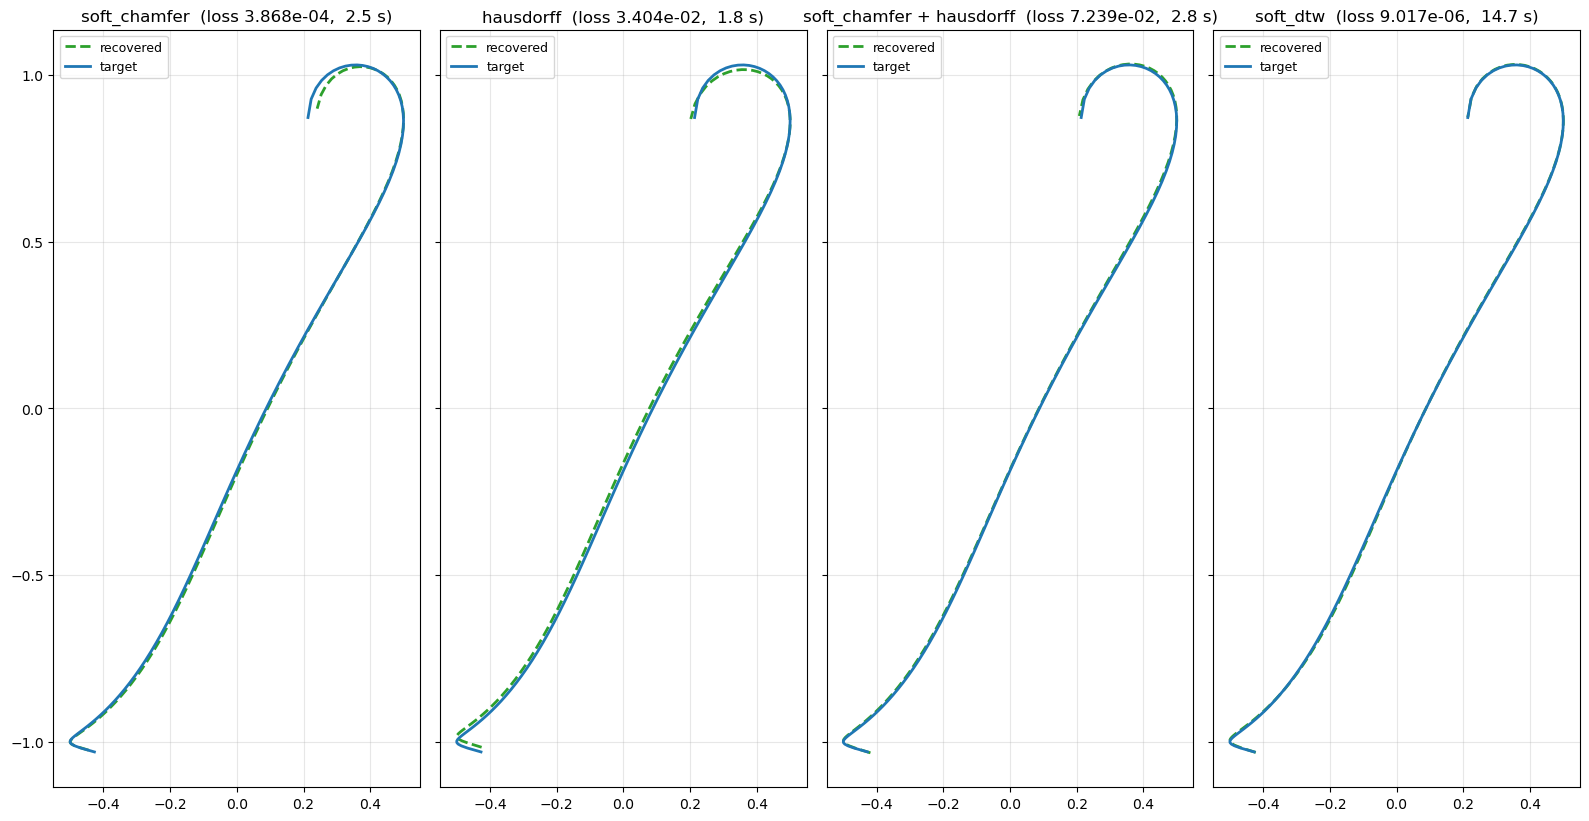

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 10), sharex=True, sharey=True)
target_n = _norm_np(arc_base)
for ax, (label, _) in zip(axes.flat, EXPERIMENTS):
    arc_m = results[label]['arc']
    if len(arc_m) >= 3:
        nm = _norm_np(arc_m)
        ax.plot(nm[:, 0], nm[:, 1], '--', color='#2ca02c', lw=2.0, label='recovered')
    ax.plot(target_n[:, 0], target_n[:, 1], '-', color='#1f77b4', lw=2.0, label='target')
    r = results[label]
    ax.set_title(f"{label}  (loss {r['hist'][-1]:.3e},  {r['elapsed']:.1f} s)")
    ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### Convergence histories on one log-scale axis


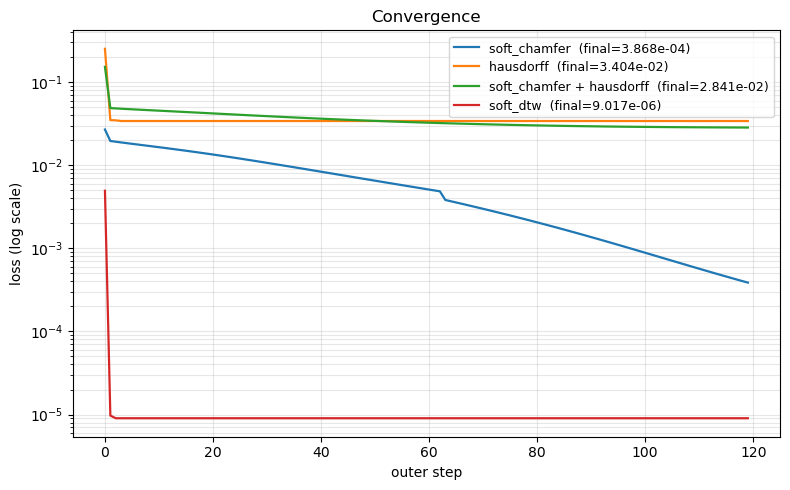

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, _ in EXPERIMENTS:
    hist_m = results[label]['hist']
    ax.semilogy(hist_m, lw=1.6, label=f"{label}  (final={hist_m[-1]:.3e})")
ax.set_xlabel('outer step'); ax.set_ylabel('loss (log scale)')
ax.set_title('Convergence')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### What to read off

- **soft_chamfer** - smooth bidirectional matching; error value drops lower than soft_chamfer + 0.5 x hausdorff but the curve is actually worse. 
- **hausdorff** - chases worst-case point; sparse gradient.
- **soft_chamfer + 0.5 x hausdorff** - composite; soft-chamfer carries
  the bulk of the gradient, hausdorff nudges outliers.
- **soft_dtw** - **divergence form** (Blondel et al. 2020) so the loss
  is always >= 0; respects monotonic alignment between curve and target.
  Much slower per eval than the other metrics (3 anti-diagonal sweeps:
  X-Y, X-X, Y-Y) but excellent fit when the parameterizations match.


## Step 8 - Save the recovered config & export to MotionGen


In [ ]:
#ts = dt.datetime.now().strftime('%Y%m%d_%H%M%S')
#out_txt = os.path.join(ARG_DIR, f'config_recovered_{ts}.txt')
#save_config_txt(out_txt, JJ, PSlice_opt, motor, fixed_nodes, path_node)
#print('saved config:', out_txt)

payload = build_motiongen_json(JJ, PSlice_opt, motor, fixed_nodes, path_node)
mg_text = json.dumps(payload, separators=(',', ':'))
n_act = len(payload['mechanism']['actuators'])
print(f"MotionGen JSON ready ({len(mg_text):,} chars, {n_act} actuator{'s' if n_act != 1 else ''})")

which = copy_to_clipboard(mg_text)
print('clipboard:', which if which else 'could not auto-copy - printing first 240 chars below')
if which is None:
    #print(mg_text[:240], '...')
    print(mg_text)


MotionGen JSON ready (2,888 chars, 1 actuator)
clipboard: windows:Win32 SetClipboardData (CF_UNICODETEXT)


## Done

You should now see, in order:
- baseline 'wrap' arc trace (non-Grashof mechanism),
- perturbed-vs-baseline diff,
- monotonically decreasing optimization history,
- three-curve overlay (baseline / perturbed / optimized),
- four-panel metric study with timings + convergence,
- recovered config saved + MotionGen JSON copied to clipboard.
